 [1] OUTLIER REJECTION SUMMARY
robot |  block |  total |  nonzero |  valid |  rejected
------------------------------------------------------------------
    2 | uwb     1 |    742 |      623 |    623 |         0
    2 | uwb     2 |    742 |      699 |    699 |         0
    2 | uwb     3 |    742 |        0 |      0 |         0
    3 | uwb     1 |    742 |      614 |    614 |         0
    3 | uwb     2 |    742 |      742 |    223 |       519
    3 | uwb     3 |    742 |        0 |      0 |         0
    4 | uwb     1 |    742 |        0 |      0 |         0
    4 | uwb     2 |    742 |      742 |    222 |       520
    4 | uwb     3 |    742 |        0 |      0 |         0

 [2] TIMELINE AND TDMA STATE
robot |   t_first |    t_last |  dur[s] |    n |  frame_min  frame_max |  sync_lost |  state
------------------------------------------------------------------------------------------------
    2 |     31965 |    211641 |  179.68 |  742 |        125        866 |      0.001 | 1
    3 |

/usr/lib/python3/dist-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]


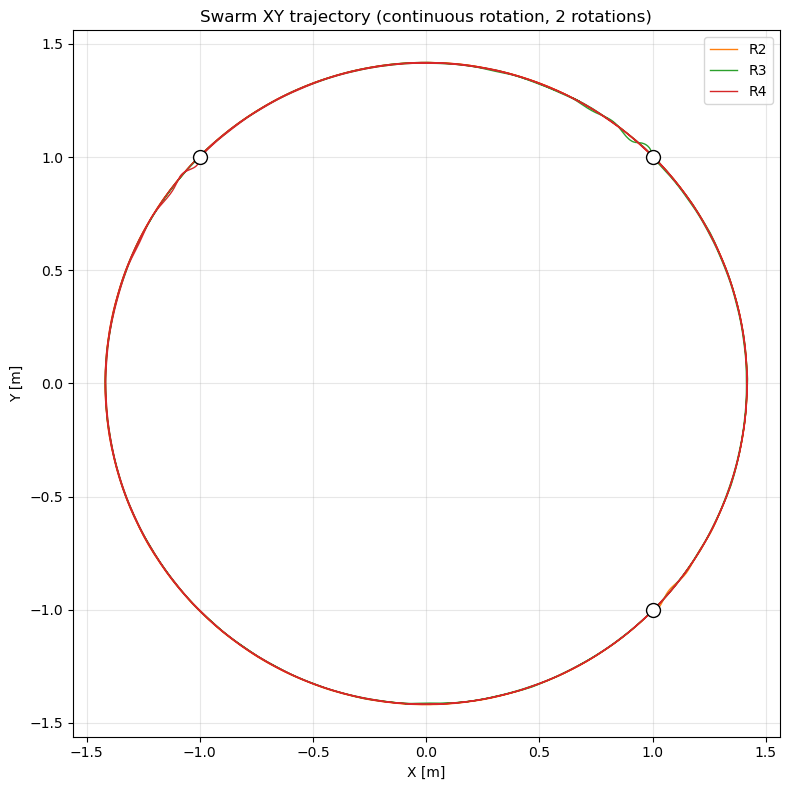

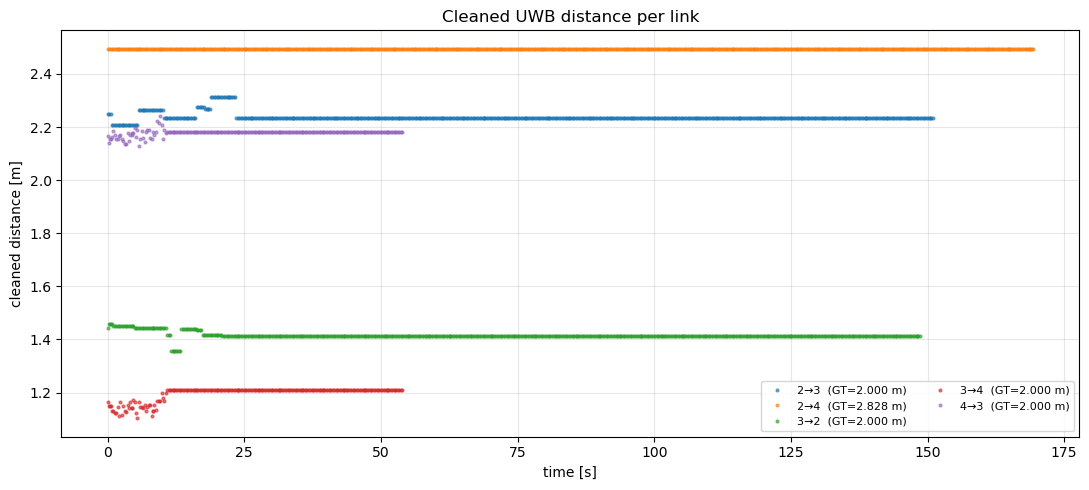

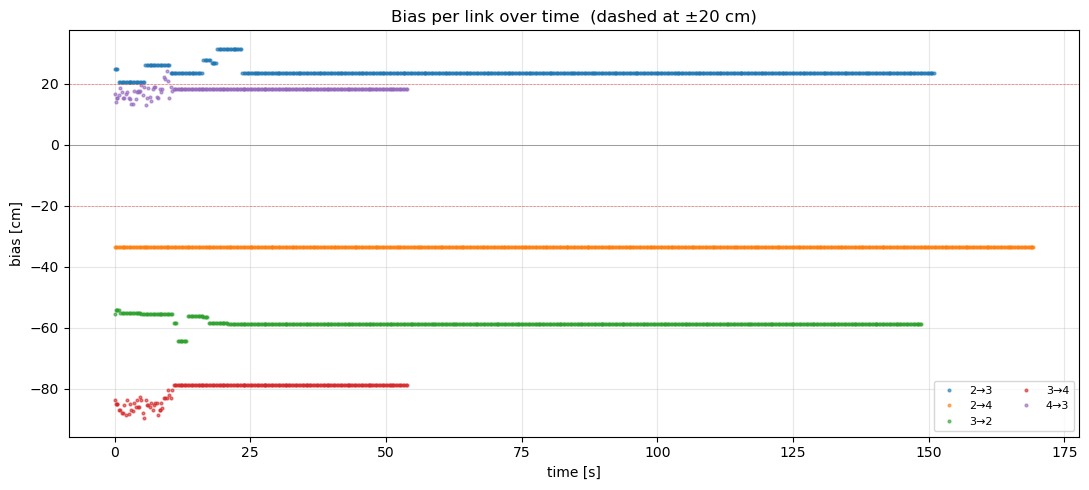

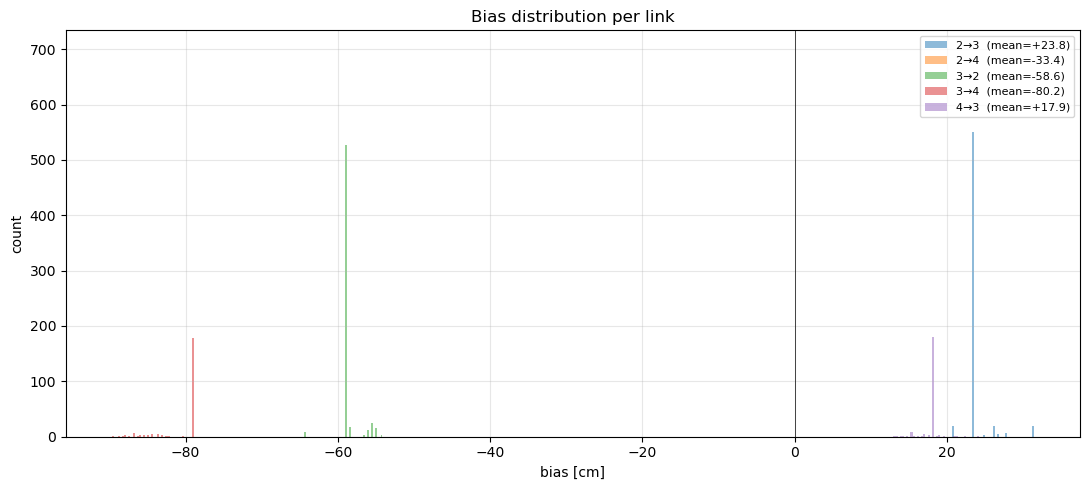

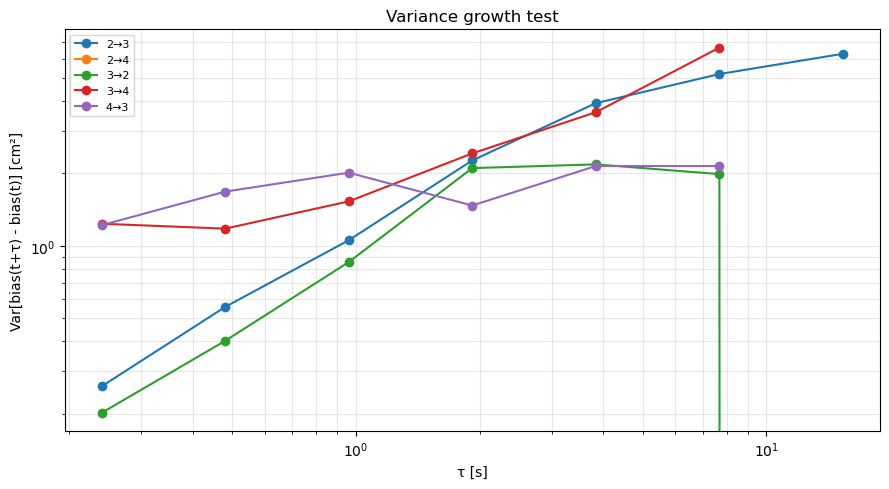

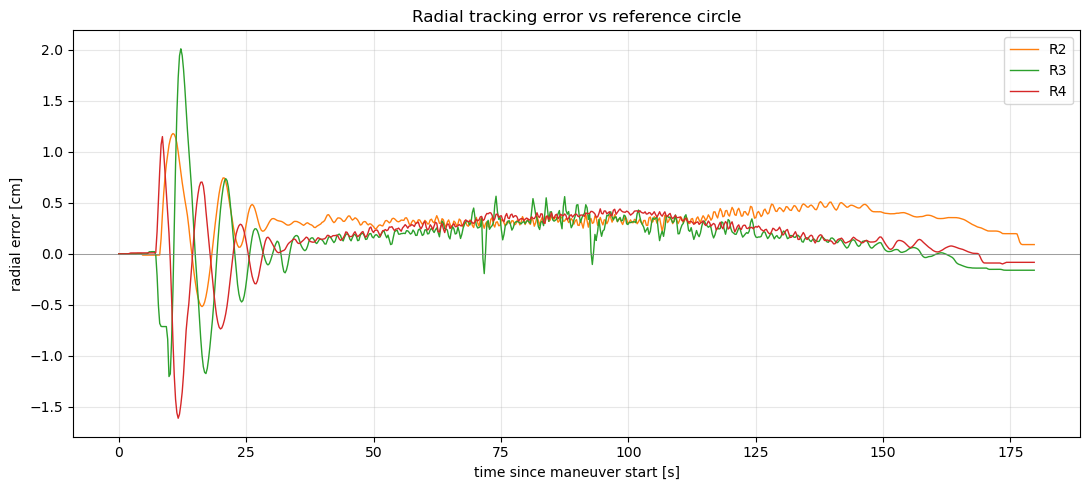

In [1]:
# ============================================================
# Comprehensive analysis — 3-robot rotation test (R2, R3, R4)
# ============================================================
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 300)

# ------------------------------------------------------------
# 0. Load
# ------------------------------------------------------------
FILES = {2: "robot_2_v2.csv", 3: "robot_3_v2.csv", 4: "robot_4_v2.csv"}

data_raw = {}
for rb, fname in FILES.items():
    p = Path(fname)
    if p.exists():
        data_raw[rb] = pd.read_csv(p)

ACTIVE = (2, 3, 4)

# ------------------------------------------------------------
# Constants
# ------------------------------------------------------------
WHEEL_RADIUS_M = 0.026850
TRACK_WIDTH = {2: 0.1248, 3: 0.1163, 4: 0.1209}

# Geometry: 3-robot right triangle on the original 2 m square
# R2 (1,-1), R3 (1,1), R4 (-1,1); L=2 means the reference
# applies R(phi) * L*r_i with r_i = (±0.5, ±0.5).
# Distances are CONSTANT throughout the rotation:
UNIT_OFFSET = {2: (+0.5, -0.5), 3: (+0.5, +0.5), 4: (-0.5, +0.5)}
L_CONST = 2.0

GT_DIST = {}
for a, b in [(2, 3), (3, 2), (2, 4), (4, 2), (3, 4), (4, 3)]:
    ra = np.array(UNIT_OFFSET[a])
    rb_ = np.array(UNIT_OFFSET[b])
    GT_DIST[(a, b)] = float(L_CONST * np.linalg.norm(ra - rb_))

# ------------------------------------------------------------
# 1. Outlier rejection
# ------------------------------------------------------------
UWB_RAW_MIN, UWB_RAW_MAX     = 0.0, 200.0
UWB_CLEAN_MIN, UWB_CLEAN_MAX = -5.0, 50.0

def is_valid_uwb(raw, clean):
    return (UWB_RAW_MIN < raw < UWB_RAW_MAX and
            UWB_CLEAN_MIN < clean < UWB_CLEAN_MAX)

print("=" * 100)
print(" [1] OUTLIER REJECTION SUMMARY")
print("=" * 100)
print(f"{'robot':>5s} | {'block':>6s} | {'total':>6s} | "
      f"{'nonzero':>8s} | {'valid':>6s} | {'rejected':>9s}")
print("-" * 66)

for rb, d in data_raw.items():
    for i in (1, 2, 3):
        raw_col = f"uwb{i}_raw"
        cln_col = f"uwb{i}_clean"
        if raw_col not in d.columns: continue
        nz = int((d[raw_col].abs() > 1e-6).sum())
        valid = int(np.sum(
            (np.abs(d[raw_col].values) > 1e-6) &
            (d[raw_col].values > UWB_RAW_MIN) & (d[raw_col].values < UWB_RAW_MAX) &
            (d[cln_col].values > UWB_CLEAN_MIN) & (d[cln_col].values < UWB_CLEAN_MAX)
        ))
        print(f"{rb:>5d} | uwb{i:>6d} | {len(d):>6d} | "
              f"{nz:>8d} | {valid:>6d} | {nz-valid:>9d}")

# ------------------------------------------------------------
# 2. Build link_data (cleaned)
# ------------------------------------------------------------
link_data = {}
for rb, d in data_raw.items():
    for i in (1, 2, 3):
        peer_col  = f"uwb{i}_peer_id"
        raw_col   = f"uwb{i}_raw"
        cln_col   = f"uwb{i}_clean"
        rssi_col  = f"uwb{i}_rssi"
        fp_col    = f"uwb{i}_fp_power"
        noise_col = f"uwb{i}_std_noise"
        if peer_col not in d.columns: continue
        for _, row in d.iterrows():
            peer = int(row[peer_col])
            raw  = row[raw_col]
            cln  = row[cln_col]
            if peer == 0:               continue
            if not is_valid_uwb(raw, cln): continue
            key = (rb, peer)
            link_data.setdefault(key, []).append({
                "t_ms":    int(row["t_ms"]),
                "raw":     raw,
                "clean":   cln,
                "rssi":    row[rssi_col],
                "fp_power": row[fp_col],
                "noise":   row[noise_col],
            })

# ------------------------------------------------------------
# 3. Timeline
# ------------------------------------------------------------
print("\n" + "=" * 100)
print(" [2] TIMELINE AND TDMA STATE")
print("=" * 100)
print(f"{'robot':>5s} | {'t_first':>9s} | {'t_last':>9s} | {'dur[s]':>7s} | "
      f"{'n':>4s} | {'frame_min':>10s} {'frame_max':>10s} | "
      f"{'sync_lost':>10s} | {'state':>6s}")
print("-" * 96)
for rb, d in data_raw.items():
    print(f"{rb:>5d} | {int(d['t_ms'].iloc[0]):>9d} | "
          f"{int(d['t_ms'].iloc[-1]):>9d} | "
          f"{(d['t_ms'].iloc[-1]-d['t_ms'].iloc[0])/1000.0:>7.2f} | "
          f"{len(d):>4d} | "
          f"{int(d['tdma_frame_id'].min()):>10d} "
          f"{int(d['tdma_frame_id'].max()):>10d} | "
          f"{d['tdma_sync_lost'].mean():>10.3f} | "
          f"{int(d['robot_state'].iloc[0])}")

# ------------------------------------------------------------
# 4. Link-level summary
# ------------------------------------------------------------
print("\n" + "=" * 100)
print(" [3] LINK-LEVEL SUMMARY (cleaned)")
print("=" * 100)
print(f"{'link':>6s} | {'n':>4s} | {'raw_mean':>11s} | "
      f"{'clean_mean':>11s} | {'clean_std':>10s} | "
      f"{'rssi_mean':>10s} | {'noise_mean':>11s}")
print("-" * 82)
for key in sorted(link_data.keys()):
    vals = link_data[key]
    if len(vals) < 3: continue
    raw_m   = np.mean([v["raw"]      for v in vals])
    clean_m = np.mean([v["clean"]    for v in vals])
    clean_s = np.std( [v["clean"]    for v in vals])
    rssi_m  = np.mean([v["rssi"]     for v in vals])
    noise_m = np.mean([v["noise"]    for v in vals])
    print(f"{key[0]}->{key[1]} | {len(vals):>4d} | "
          f"{raw_m:>+11.3f} | {clean_m:>+11.3f} | "
          f"{clean_s:>10.3f} | {rssi_m:>+10.2f} | {noise_m:>11.1f}")

# ------------------------------------------------------------
# 5. Bias vs constant ground truth
# ------------------------------------------------------------
print("\n" + "=" * 100)
print(" [4] BIAS vs CONSTANT GROUND TRUTH")
print("=" * 100)
print("  For rigid rotation, GT distance is constant for each pair.")
print("  bias(t) = clean_dist(t) - GT.")
print(f"\n{'link':>6s} | {'n':>4s} | {'GT':>7s} | "
      f"{'bias_mean':>10s} | {'bias_std':>10s} | "
      f"{'bias_min':>10s} | {'bias_max':>10s}")
print("-" * 78)

bias_records = {}
for key in sorted(link_data.keys()):
    if key not in GT_DIST: continue
    gt = GT_DIST[key]
    vals = link_data[key]
    if len(vals) < 10: continue
    t_arr   = np.array([v["t_ms"] for v in vals])
    cln_arr = np.array([v["clean"] for v in vals])
    bias_cm = (cln_arr - gt) * 100
    bias_records[key] = {"t_ms": t_arr, "clean": cln_arr, "bias_cm": bias_cm,
                         "gt": gt}
    print(f"{key[0]}->{key[1]} | {len(vals):>4d} | {gt:>7.3f} | "
          f"{bias_cm.mean():>+10.2f} | {bias_cm.std():>10.2f} | "
          f"{bias_cm.min():>+10.2f} | {bias_cm.max():>+10.2f}")

# ------------------------------------------------------------
# 6. Variance growth test  Var[bias(t+tau) - bias(t)] vs tau
# ------------------------------------------------------------
print("\n" + "=" * 100)
print(" [5] VARIANCE GROWTH TEST  (random walk vs mean-reverting)")
print("=" * 100)
print("  For each link, compute Var[bias(t+tau) - bias(t)] over tau.")
print("  Linear growth => random walk. Saturation => mean-reverting.\n")

TAUS_S = [0.24, 0.48, 0.96, 1.92, 3.84, 7.68, 15.36]

for key in sorted(bias_records.keys()):
    rec = bias_records[key]
    t = rec["t_ms"] / 1000.0
    b = rec["bias_cm"]

    # sort by time
    order = np.argsort(t)
    t = t[order]; b = b[order]

    results = []
    for tau_s in TAUS_S:
        vals = []
        # For each i, find j such that t[j] - t[i] ~ tau_s
        for i in range(len(t)):
            j_target = t[i] + tau_s
            j_idx = np.searchsorted(t, j_target)
            if j_idx >= len(t): break
            if abs(t[j_idx] - j_target) < 0.15:
                vals.append(b[j_idx] - b[i])
        if len(vals) > 5:
            results.append((tau_s, np.var(vals)))

    if not results: continue
    print(f"  {key[0]}->{key[1]}:")
    for tau_s, v in results:
        print(f"    τ = {tau_s:>5.2f} s   Var = {v:>10.2f} cm²")

# ------------------------------------------------------------
# 7. Autocorrelation function of bias
# ------------------------------------------------------------
print("\n" + "=" * 100)
print(" [6] AUTOCORRELATION OF BIAS  (first 10 lags of 240 ms)")
print("=" * 100)

for key in sorted(bias_records.keys()):
    rec = bias_records[key]
    t = rec["t_ms"] / 1000.0
    b = rec["bias_cm"]
    order = np.argsort(t)
    b = b[order]
    if len(b) < 20: continue
    b = b - b.mean()
    n = len(b)
    acf = []
    for lag in range(0, 10):
        if lag == 0:
            acf.append(1.0)
        else:
            acf.append(float(np.corrcoef(b[:-lag], b[lag:])[0, 1]))
    print(f"  {key[0]}->{key[1]}: " +
          " ".join(f"{a:+.3f}" for a in acf))

# ------------------------------------------------------------
# 8. PLOT — Swarm XY trajectory
# ------------------------------------------------------------
colors = {2: "tab:orange", 3: "tab:green", 4: "tab:red"}

fig, ax = plt.subplots(figsize=(8, 8))
for rb, d in data_raw.items():
    ax.plot(d["x"], d["y"], color=colors[rb], lw=1.0, label=f"R{rb}")
for rb in (2, 3, 4):
    rx, ry = UNIT_OFFSET[rb]
    ax.plot(L_CONST * rx, L_CONST * ry, "o", color=colors[rb], ms=10,
            markeredgecolor="black", markerfacecolor="white")
ax.set_aspect("equal")
ax.set_xlabel("X [m]")
ax.set_ylabel("Y [m]")
ax.set_title("Swarm XY trajectory (continuous rotation, 2 rotations)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("p1_trajectory.png", dpi=120)
plt.show()

# ------------------------------------------------------------
# 9. PLOT — Cleaned distance per link over time
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 5))
for key in sorted(bias_records.keys()):
    rec = bias_records[key]
    t_rel = rec["t_ms"] / 1000.0 - rec["t_ms"][0] / 1000.0
    ax.plot(t_rel, rec["clean"], ".", ms=4, alpha=0.6,
            label=f"{key[0]}→{key[1]}  (GT={rec['gt']:.3f} m)")
ax.set_xlabel("time [s]")
ax.set_ylabel("cleaned distance [m]")
ax.set_title("Cleaned UWB distance per link")
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("p2_cleaned_dist.png", dpi=120)
plt.show()

# ------------------------------------------------------------
# 10. PLOT — Bias per link over time
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 5))
for key in sorted(bias_records.keys()):
    rec = bias_records[key]
    t_rel = rec["t_ms"] / 1000.0 - rec["t_ms"][0] / 1000.0
    ax.plot(t_rel, rec["bias_cm"], ".", ms=4, alpha=0.6,
            label=f"{key[0]}→{key[1]}")
ax.axhline(0, color="gray", lw=0.5)
ax.axhline(+20, color="red", ls="--", lw=0.5, alpha=0.5)
ax.axhline(-20, color="red", ls="--", lw=0.5, alpha=0.5)
ax.set_xlabel("time [s]")
ax.set_ylabel("bias [cm]")
ax.set_title("Bias per link over time  (dashed at ±20 cm)")
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("p3_bias_time.png", dpi=120)
plt.show()

# ------------------------------------------------------------
# 11. PLOT — Bias histogram per link
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 5))
for key in sorted(bias_records.keys()):
    rec = bias_records[key]
    ax.hist(rec["bias_cm"], bins=40, alpha=0.5,
            label=f"{key[0]}→{key[1]}  (mean={rec['bias_cm'].mean():+.1f})")
ax.axvline(0, color="black", lw=0.5)
ax.set_xlabel("bias [cm]")
ax.set_ylabel("count")
ax.set_title("Bias distribution per link")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("p4_bias_hist.png", dpi=120)
plt.show()

# ------------------------------------------------------------
# 12. PLOT — Variance growth
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5))
for key in sorted(bias_records.keys()):
    rec = bias_records[key]
    t = rec["t_ms"] / 1000.0
    b = rec["bias_cm"]
    order = np.argsort(t)
    t = t[order]; b = b[order]
    taus_plot, vars_plot = [], []
    for tau_s in TAUS_S:
        vals = []
        for i in range(len(t)):
            j_target = t[i] + tau_s
            j_idx = np.searchsorted(t, j_target)
            if j_idx >= len(t): break
            if abs(t[j_idx] - j_target) < 0.15:
                vals.append(b[j_idx] - b[i])
        if len(vals) > 5:
            taus_plot.append(tau_s)
            vars_plot.append(np.var(vals))
    ax.plot(taus_plot, vars_plot, "o-", label=f"{key[0]}→{key[1]}")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("τ [s]")
ax.set_ylabel("Var[bias(t+τ) - bias(t)] [cm²]")
ax.set_title("Variance growth test")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, which="both")
plt.tight_layout()
plt.savefig("p5_variance_growth.png", dpi=120)
plt.show()

# ------------------------------------------------------------
# 13. PLOT — Trajectory tracking error
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 5))
for rb, d in data_raw.items():
    if "robot_state" not in d.columns: continue
    dr = d[d["robot_state"] == 1]
    if len(dr) < 10: continue
    # For continuous rotation with constant L, the reference
    # is L * R(phi(t)) * r_i. We can recover phi(t) from the
    # controller's omega_cmd, but simpler: use each robot's own
    # position vs the reference circle of radius L * |r_i|.
    rx, ry = UNIT_OFFSET[rb]
    r_ref = L_CONST * np.hypot(rx, ry)
    r_meas = np.hypot(dr["x"], dr["y"])
    r_err_cm = (r_meas - r_ref) * 100
    t_rel = (dr["t_ms"] - dr["t_ms"].iloc[0]) / 1000.0
    ax.plot(t_rel, r_err_cm, color=colors[rb], lw=1.0, label=f"R{rb}")
ax.axhline(0, color="gray", lw=0.5)
ax.set_xlabel("time since maneuver start [s]")
ax.set_ylabel("radial error [cm]")
ax.set_title("Radial tracking error vs reference circle")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("p6_radial_error.png", dpi=120)
plt.show()